In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from statsmodels.tsa.stattools import (
    coint,
    adfuller
)

import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv(
    "nifty_50_comp_price_data.csv",
    index_col=0,
    parse_dates=True
)

data = data.dropna(axis=1)

In [2]:
def backtest_pair_walkforward(
    stock1,
    stock2,
    train,
    test,
    window=252,
    entry_z=2,
    exit_z=0
):

    combined = pd.concat([
        train[[stock1, stock2]],
        test[[stock1, stock2]]
    ])

    rolling_beta = (
        combined[stock1]
        .rolling(window)
        .cov(combined[stock2])
        /
        combined[stock2]
        .rolling(window)
        .var()
    )

    spread = (
        combined[stock1]
        - rolling_beta * combined[stock2]
    )

    rolling_mean = (
        spread
        .rolling(window)
        .mean()
    )

    rolling_std = (
        spread
        .rolling(window)
        .std()
    )

    zscore = (
        spread
        - rolling_mean
    ) / rolling_std

    zscore = zscore.loc[
        test.index
    ]

    beta_test = rolling_beta.loc[
        test.index
    ]

    position = pd.Series(
        0,
        index=test.index
    )

    current_position = 0

    for i in range(len(zscore)):

        z = zscore.iloc[i]

        if np.isnan(z):
            continue

        if current_position == 0:

            if z > entry_z:
                current_position = -1

            elif z < -entry_z:
                current_position = 1

        elif current_position == 1:

            if z >= exit_z:
                current_position = 0

        elif current_position == -1:

            if z <= -exit_z:
                current_position = 0

        position.iloc[i] = current_position

    stock1_ret = (
        test[stock1]
        .pct_change()
    )

    stock2_ret = (
        test[stock2]
        .pct_change()
    )

    spread_ret = (
        stock1_ret
        -
        beta_test * stock2_ret
    )

    strategy_ret = (
        position.shift(1)
        *
        spread_ret
    )

    return strategy_ret.fillna(0)

In [8]:
def find_pairs(train):

    returns = train.pct_change()

    corr_matrix = returns.corr()

    candidate_pairs = []

    for i in range(len(corr_matrix.columns)):

        for j in range(i + 1,
                       len(corr_matrix.columns)):

            stock1 = corr_matrix.columns[i]
            stock2 = corr_matrix.columns[j]

            corr = corr_matrix.iloc[i, j]

            if corr > 0.40:

                candidate_pairs.append(
                    [
                        stock1,
                        stock2,
                        corr
                    ]
                )

    candidate_pairs = pd.DataFrame(
        candidate_pairs,
        columns=[
            "Stock1",
            "Stock2",
            "Correlation"
        ]
    )

    results = []

    for _, row in candidate_pairs.iterrows():

        stock1 = row["Stock1"]
        stock2 = row["Stock2"]

        try:

            score, coint_p, _ = coint(
                train[stock1],
                train[stock2]
            )

            beta = np.polyfit(
                train[stock2],
                train[stock1],
                1
            )[0]

            spread = (
                train[stock1]
                - beta * train[stock2]
            )

            adf_p = adfuller(
                spread.dropna()
            )[1]

            results.append([
                stock1,
                stock2,
                row["Correlation"],
                coint_p,
                adf_p
            ])

        except:
            continue

    pairs_df = pd.DataFrame(
        results,
        columns=[
            "Stock1",
            "Stock2",
            "Correlation",
            "Cointegration_P",
            "ADF_P"
        ]
    )

    strong_pairs = pairs_df[
        (pairs_df["Cointegration_P"] < 0.05)
        &
        (pairs_df["ADF_P"] < 0.05)
    ]

    strong_pairs = strong_pairs.sort_values(
        [
            "Cointegration_P",
            "ADF_P"
        ]
    )

    return strong_pairs.head(10)

In [9]:
windows = [

    (
        "2020-01-01",
        "2023-12-31",
        "2024-01-01",
        "2024-12-31"
    ),

    (
        "2021-01-01",
        "2024-12-31",
        "2025-01-01",
        "2025-12-31"
    ),

    (
        "2022-01-01",
        "2025-12-31",
        "2026-01-01",
        "2026-12-31"
    )

]

In [10]:
all_returns = []

selected_pairs_each_year = {}

In [11]:
for train_start, train_end, test_start, test_end in windows:

    train = data.loc[
        train_start:train_end
    ]

    test = data.loc[
        test_start:test_end
    ]

    selected_pairs = find_pairs(
        train
    )

    selected_pairs_each_year[
        test_start[:4]
    ] = selected_pairs

    pair_returns = pd.DataFrame()

    for _, row in selected_pairs.iterrows():

        stock1 = row["Stock1"]
        stock2 = row["Stock2"]

        pair_name = (
            f"{stock1}_{stock2}"
        )

        pair_returns[pair_name] = (
            backtest_pair_walkforward(
                stock1,
                stock2,
                train,
                test
            )
        )

    active_pairs = (
        pair_returns != 0
    ).sum(axis=1)

    portfolio_ret = (
        pair_returns.sum(axis=1)
        /
        active_pairs.replace(
            0,
            np.nan
        )
    )

    portfolio_ret = (
        portfolio_ret.fillna(0)
    )

    all_returns.append(
        portfolio_ret
    )

In [12]:
portfolio_ret = pd.concat(
    all_returns
)

portfolio_ret = portfolio_ret.sort_index()

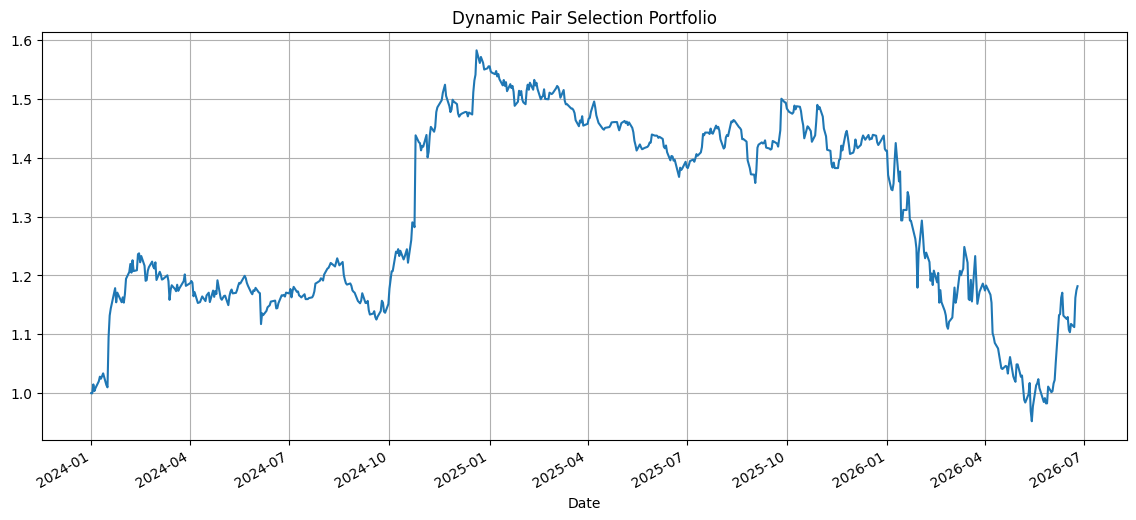

In [13]:
equity_curve = (
    1 + portfolio_ret
).cumprod()

plt.figure(figsize=(14,6))

equity_curve.plot()

plt.title(
    "Dynamic Pair Selection Portfolio"
)

plt.grid(True)

plt.show()

In [14]:
total_return = (
    equity_curve.iloc[-1] - 1
)

years = (
    len(portfolio_ret)
    / 252
)

cagr = (
    equity_curve.iloc[-1]
) ** (1 / years) - 1

sharpe = (
    portfolio_ret.mean()
    /
    portfolio_ret.std()
) * np.sqrt(252)

rolling_max = (
    equity_curve.cummax()
)

drawdown = (
    equity_curve
    /
    rolling_max
    - 1
)

max_dd = drawdown.min()

print(
    f"Total Return: {total_return:.2%}"
)

print(
    f"CAGR: {cagr:.2%}"
)

print(
    f"Sharpe: {sharpe:.2f}"
)

print(
    f"Max Drawdown: {max_dd:.2%}"
)

Total Return: 18.17%
CAGR: 7.08%
Sharpe: 0.41
Max Drawdown: -39.83%


In [15]:
dynamic_results = pd.DataFrame({
    "Metric":[
        "Total Return",
        "CAGR",
        "Sharpe",
        "Max Drawdown"
    ],
    "Value":[
        total_return,
        cagr,
        sharpe,
        max_dd
    ]
})

dynamic_results.to_csv(
    "dynamic_selection_results.csv",
    index=False
)